In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from urllib.parse import urlparse
import requests
from bs4 import BeautifulSoup
import ollama
import time
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
def search_strategy_urls(query, api_key):
    url = "https://serpapi.com/search"

    params = {
        "q": query,
        "api_key": api_key,
        "engine": "google"
    }

    response = requests.get(url, params=params)
    data = response.json()

    urls = []

    for result in data.get("organic_results", []):
        if "link" in result:
            urls.append(result["link"])

    return urls

queries = [
    # General
    'best trading strategies explained',
    'different types of trading strategies',
    'popular trading strategies examples',
    'systematic trading strategies',
    'rules based trading strategies',
    'technical trading systems',
    'profitable trading methods explained',
    'trading strategy entry exit rules',
    'stock market trading systems',
    'active trading strategies',

    # Momentum
    'momentum trading strategy',
    'momentum investing strategy rules',
    'price momentum trading system',
    'relative strength momentum strategy',
    'cross sectional momentum strategy',
    'time series momentum strategy',
    'dual momentum trading strategy',
    'momentum breakout strategy',
    'momentum swing trading system',
    'momentum strategy stocks',

    # Mean reversion / reversal
    'mean reversion trading strategy',
    'mean reverting stock strategy',
    'price reversal trading strategy',
    'contrarian trading strategy',
    'oversold overbought trading strategy',
    'RSI mean reversion strategy',
    'Bollinger Band mean reversion strategy',
    'moving average mean reversion strategy',
    'short term reversal strategy stocks',
    'statistical mean reversion trading',

    # Trend following
    'trend following trading strategy',
    'trend trading system',
    'moving average trend strategy',
    'moving average crossover strategy',
    'EMA crossover trading strategy',
    'MACD trend trading strategy',
    'ADX trend trading strategy',
    'Donchian channel trading strategy',
    'Turtle trading strategy',
    'long term trend following system',

    # Breakout
    'breakout trading strategy',
    'price breakout trading system',
    'resistance breakout strategy',
    'support breakout trading strategy',
    'channel breakout trading strategy',
    'Donchian breakout strategy',
    'volatility breakout strategy',
    'opening range breakout strategy',
    '52 week high breakout strategy',
    'consolidation breakout strategy stocks',

    # Range / price action
    'range trading strategy',
    'support resistance trading strategy',
    'price action trading strategy',
    'channel trading strategy',
    'candlestick trading strategy',
    'chart pattern trading strategy',
    'pivot point trading strategy',
    'supply demand trading strategy',
    'inside bar trading strategy',
    'price action swing trading system',

    # Indicators
    'RSI trading strategy',
    'MACD trading strategy',
    'Bollinger Bands trading strategy',
    'stochastic oscillator trading strategy',
    'VWAP trading strategy',
    'volume trading strategy',
    'moving average trading strategy',
    'ATR trading strategy',
    'Ichimoku trading strategy',
    'CCI trading strategy',

    # Quant / arbitrage
    'quantitative trading strategies examples',
    'algorithmic trading strategies examples',
    'statistical arbitrage strategy',
    'pairs trading strategy',
    'market neutral trading strategy',
    'factor trading strategy',
    'equity market neutral strategy',
    'relative value trading strategy',
    'cointegration pairs trading strategy',
    'quantitative momentum strategy',

    # Day / short-term
    'day trading strategy examples',
    'intraday trading strategies',
    'scalping trading strategy',
    'opening range trading strategy',
    'gap trading strategy',
    'VWAP intraday strategy',
    'intraday momentum strategy',
    'intraday mean reversion strategy',
    'first hour trading strategy',
    'end of day trading strategy',

    # Swing / position / long-term
    'swing trading strategy examples',
    'position trading strategy',
    'medium term trading strategies',
    'weekly trading strategies stocks',
    'long term stock trading strategy',
    'trend following position trading',
    'multi timeframe trading strategy',
    'daily chart trading strategy',
    'weekly momentum strategy',
    'swing breakout trading strategy',

    # Different assets — helps asset_type diversity
    'forex trading strategies',
    'ETF trading strategies',
    'futures trading strategies',
    'index trading strategies',
    'commodity trading strategies',
    'currency momentum strategy',
    'forex mean reversion strategy',
    'futures trend following strategy',
    'ETF momentum strategy',
    'index mean reversion strategy'
]

all_urls = []
API_KEY = "b627b29297e736b18078a2fd5cbcfb770d7fa7b0814701711428b0241d8037c3"

for query in queries:
    urls = search_strategy_urls(query, API_KEY)
    all_urls.extend(urls)

all_urls = list(set(all_urls))

In [3]:
def scrape_strategy(url):
    domain = urlparse(url).netloc
    source = domain.removeprefix("www.").split(".")[0]

    try:
        response = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )

        if response.status_code != 200:
            print(f"Failed: {url} ({response.status_code})")
            return None

        soup = BeautifulSoup(response.text, "html.parser")

        for tag in soup(["script", "style", "nav", "footer", "header"]):
            tag.decompose()

        text = soup.get_text(" ", strip=True)

        return {
            "source": source,
            "url": url,
            "raw_text": text
        }

    except requests.RequestException as e:
        return {
            "url": url,
            "raw_text": None,
            "error": str(e)
        }

In [4]:
strategies = []

for url in all_urls:
    strategy = scrape_strategy(url)

    if strategy is not None:
        strategies.append(strategy)

for i, strategy in enumerate(strategies, start=1):
    strategy["id"] = i

with open("data/raw_strategies.json", "w", encoding="utf-8") as f:
    json.dump(strategies, f, indent=4, ensure_ascii=False)

Failed: https://www.cmegroup.com/education/courses/options-on-futures-for-equity-traders/trading-options-on-futures-using-strategies-you-already-know (403)
Failed: https://www.investopedia.com/terms/m/momentum.asp (402)
Failed: https://www.merriam-webster.com/dictionary/price (403)
Failed: https://www.reddit.com/r/Daytrading/comments/13wgma0/hello_scalpers_well_which_scalping_strategy_do/ (403)
Failed: https://www.tradu.com/en/guide/trading/position-trading/ (403)
Failed: https://sgt.markets/unlocking-the-secrets-of-the-stochastic-oscillator-a-beginners-guide/ (503)
Failed: https://www.reddit.com/r/swingtrading/comments/1fy6c45/im_a_professional_trader_and_this_is_my_guide_on/ (403)
Failed: https://hudsonthames.org/an-introduction-to-cointegration/ (406)
Failed: https://www.investopedia.com/articles/trading/08/atr.asp (402)
Failed: https://www.avatrade.com/education/technical-analysis-indicators-strategies/support-and-resistance (403)
Failed: https://medium.com/@rul.a/the-best-trading-

In [5]:
with open("data/raw_strategies.json", "r", encoding="utf-8") as f:
    strategies = json.load(f)

In [6]:
def extract_strategy(raw_text):
    prompt = f"""
Extract ONE primary stock trading strategy from the text below.

Return exactly:

{{
  "strategy_type": Momentum, Mean Reversion, Trend Following, Breakout,
               Arbitrage, Pairs Trading, Scalping

  "direction": Long, Short, Long/Short, Market Neutral

  "asset_type": Stocks, ETFs, Forex, Futures, Crypto, Multiple

  "timeframe": Intraday, Short-term, Medium-term, Long-term
}}

Rules:
- Extract only ONE primary strategy.
- strategy_type, direction, asset_type, and timeframe must each be
  either ONE string or null.
- Use null, never "Unknown".
- If multiple timeframes appear, choose the timeframe that belongs to
  the primary strategy.
- Do not invent missing information.
- Ignore unrelated webpage content.

TEXT:
{raw_text[:8000]}
"""

    response = ollama.chat(
        model="llama3.2:3b",
        messages=[
            {"role": "user", "content": prompt}
        ],
        format="json"
    )

    return json.loads(response["message"]["content"])

In [7]:
structured_strategies = []

for strategy in strategies:
    try:
        structured = extract_strategy(strategy["raw_text"])

        structured["id"] = strategy["id"]
        structured["source"] = strategy["source"]
        structured["url"] = strategy["url"]

        structured_strategies.append(structured)

        print(f"Finished {strategy['id']}")

        time.sleep(1)

    except Exception as e:
        print(f"Failed on strategy {strategy['id']}: {e}")

Finished 1
Finished 2
Finished 3
Finished 4
Finished 5
Finished 6
Finished 7
Finished 8
Finished 9
Finished 10
Finished 11
Finished 12
Finished 13
Finished 14
Finished 15
Finished 16
Finished 17
Finished 18
Finished 19
Finished 20
Finished 21
Finished 22
Finished 23
Finished 24
Finished 25
Finished 26
Finished 27
Finished 28
Finished 29
Failed on strategy 30: Unterminated string starting at: line 66 column 3 (char 2272)
Finished 31
Finished 32
Finished 33
Finished 34
Finished 35
Finished 36
Finished 37
Finished 38
Finished 39
Finished 40
Finished 41
Finished 42
Finished 43
Finished 44
Finished 45
Finished 46
Finished 47
Finished 48
Finished 49
Finished 50
Finished 51
Finished 52
Finished 53
Finished 54
Finished 55
Finished 56
Finished 57
Finished 58
Finished 59
Finished 60
Failed on strategy 61: Unterminated string starting at: line 3 column 16 (char 54)
Finished 62
Finished 63
Failed on strategy 64: Unterminated string starting at: line 4 column 17 (char 85)
Finished 65
Finished 66
Fi

In [8]:
def is_valid_strategy(s):
    fields = ["strategy_type", "direction", "asset_type", "timeframe"]
    return sum(s.get(field) is not None for field in fields) >= 3

In [9]:
old_strategies = structured_strategies[:]
structured_strategies = [
    s for s in structured_strategies
    if is_valid_strategy(s)
]

In [10]:
with open("data/structured_strategies.json", "w", encoding="utf-8") as f:
    json.dump(structured_strategies, f, indent=4, ensure_ascii=False)

In [11]:
with open("data/structured_strategies.json", "r", encoding="utf-8") as f:
    structured_strategies = json.load(f)

In [12]:
df = pd.DataFrame(structured_strategies)

df.head()

,strategy_type,direction,asset_type,timeframe,id,source,url,lookback_period,holding_period,number_of_stocks_long,number_of_stocks_short,"In, this is a primary stock trading strategy - the 5-8-13. Trading Strategy: The 5-8-13 EMA crossover is used to detect momentum shifts in short-term price movements and generate buy/sell signals for stocks.",The Momentum Cross Over
0,Mean Reversion,Long/Short,Stocks,Long-term,1,sofi,https://www.sofi.com/learn/content/mean-revers...,NaN,NaN,NaN,NaN,NaN,NaN
1,Momentum,Long/Short,Stocks,Intraday,2,ninjatrader,https://www.ninjatrader.com/futures/blogs/comm...,NaN,NaN,NaN,NaN,NaN,NaN
2,Momentum,NaN,Stocks,Intraday,3,corporatefinanceinstitute,https://corporatefinanceinstitute.com/resource...,NaN,NaN,NaN,NaN,NaN,NaN
3,Mean Reversion,Long/Short,Stocks,Intraday,4,atlasca,https://atlasca.com/short-term-reversal/,NaN,NaN,NaN,NaN,NaN,NaN
4,Mean Reversion,Long/Short,Stocks,Intraday,5,tradeciety,https://tradeciety.com/how-to-trade-consolidat...,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df["asset_type"] = (
    df["asset_type"]
    .astype(str)
    .str.lower()
    .replace({
        "stocks": "stock",
        "nan": None
    })
)

df["timeframe"] = (
    df["timeframe"]
    .astype(str)
    .str.lower()
    .replace({
        "1d": "daily",
        "nan": None
    })
)

df["strategy_type"] = (
    df["strategy_type"]
    .astype(str)
    .str.lower()
    .replace({
        "breakout strategy": "breakout",
        "momentum trading": "momentum",
        "momentum portfolio": "momentum",
        "nan": None
    })
)

In [14]:
categorical = [
    "strategy_type",
    "direction",
    "asset_type",
    "timeframe"
]

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_categorical = encoder.fit_transform(df[categorical])

In [15]:
X_categorical.shape

(369, 58)

In [16]:
X_categorical[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0.])

In [17]:
encoder.get_feature_names_out()

array(['strategy_type_algorithmic trading', 'strategy_type_breakout',
       'strategy_type_breakout and run',
       'strategy_type_consolidation breakout', 'strategy_type_contrarian',
       'strategy_type_contrarian trading',
       'strategy_type_equity market neutral',
       'strategy_type_equity-market-neutral', 'strategy_type_gap trading',
       'strategy_type_ichimoku cloud trading', 'strategy_type_inside bar',
       'strategy_type_market neutral', 'strategy_type_mean reversion',
       'strategy_type_medium term trading', 'strategy_type_momentum',
       'strategy_type_momentum breakout',
       'strategy_type_multi-timeframe analysis',
       'strategy_type_opening range breakout',
       'strategy_type_pair trading', 'strategy_type_pairs trading',
       'strategy_type_position trading',
       'strategy_type_prepayment arbitrage',
       'strategy_type_range trading',
       'strategy_type_relative value arbitrage', 'strategy_type_reversal',
       'strategy_type_scalpin

In [18]:
X_categorical

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(369, 58))

In [19]:
X_categorical = encoder.fit_transform(df[categorical])

print(X_categorical.shape)
print(encoder.get_feature_names_out())

(369, 58)
['strategy_type_algorithmic trading' 'strategy_type_breakout'
 'strategy_type_breakout and run' 'strategy_type_consolidation breakout'
 'strategy_type_contrarian' 'strategy_type_contrarian trading'
 'strategy_type_equity market neutral'
 'strategy_type_equity-market-neutral' 'strategy_type_gap trading'
 'strategy_type_ichimoku cloud trading' 'strategy_type_inside bar'
 'strategy_type_market neutral' 'strategy_type_mean reversion'
 'strategy_type_medium term trading' 'strategy_type_momentum'
 'strategy_type_momentum breakout'
 'strategy_type_multi-timeframe analysis'
 'strategy_type_opening range breakout' 'strategy_type_pair trading'
 'strategy_type_pairs trading' 'strategy_type_position trading'
 'strategy_type_prepayment arbitrage' 'strategy_type_range trading'
 'strategy_type_relative value arbitrage' 'strategy_type_reversal'
 'strategy_type_scalping' 'strategy_type_statistical arbitrage'
 'strategy_type_supply and demand trading' 'strategy_type_swing trading'
 'strategy_t

In [20]:
X = X_categorical

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

clusters = kmeans.fit_predict(X)

In [21]:
df["cluster"] = clusters

In [22]:
pd.set_option("display.max_rows", None)

df[
    [
        "strategy_type",
        "direction",
        "asset_type",
        "timeframe",
        "cluster"
    ]
].sort_values("cluster")

,strategy_type,direction,asset_type,timeframe,cluster
31,mean reversion,Long/Short,stock,medium-term,0
365,breakout,Long/Short,stock,intraday,0
361,breakout,Long/Short,stock,intraday,0
360,mean reversion,Long/Short,stock,intraday,0
357,contrarian trading,Long/Short,stock,long-term,0
356,mean reversion,Long/Short,stock,intraday,0
347,mean reversion,Long/Short,stock,intraday,0
343,mean reversion,Long/Short,stock,intraday,0
342,mean reversion,Long/Short,stock,medium-term,0
341,mean reversion,Long/Short,stock,medium-term,0


In [23]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [24]:
X_pca.shape

(369, 2)

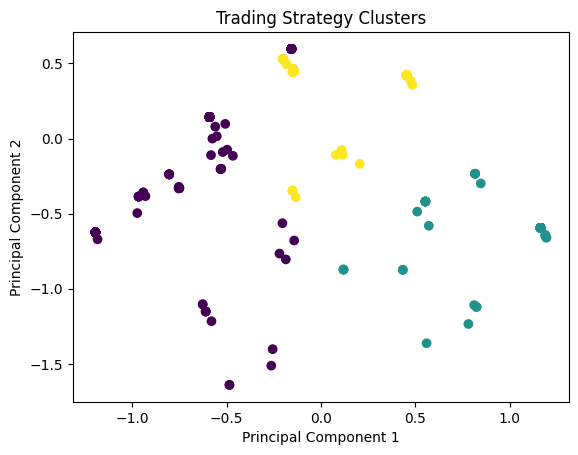

In [25]:


plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Trading Strategy Clusters")

plt.show()

In [26]:
pd.set_option("display.max_rows", None)
df[
    [
        "strategy_type",
        "direction",
        "asset_type",
        "timeframe",
        "cluster"
    ]
].sort_values("cluster")

,strategy_type,direction,asset_type,timeframe,cluster
31,mean reversion,Long/Short,stock,medium-term,0
365,breakout,Long/Short,stock,intraday,0
361,breakout,Long/Short,stock,intraday,0
360,mean reversion,Long/Short,stock,intraday,0
357,contrarian trading,Long/Short,stock,long-term,0
356,mean reversion,Long/Short,stock,intraday,0
347,mean reversion,Long/Short,stock,intraday,0
343,mean reversion,Long/Short,stock,intraday,0
342,mean reversion,Long/Short,stock,medium-term,0
341,mean reversion,Long/Short,stock,medium-term,0
